# T-TEST DE DOS MUESTRAS INDEPENDIENTES: TEST A/B

Somos Científicos de Datos en una tienda online. El equipo de marketing ha desarrollado una nueva versión de la página del producto (versión B) con un diseño más moderno. 

**Quieren saber si esta nueva versión incrementa el gasto promedio por usuario en comparación con la versión actual (versión A)**

## 1. Desarrollo de la prueba de hipótesis

Observemos que en este caso no conocemos ni las medias ni las desviaciones estándar de las poblaciones y que queremos comparar dos grupos de compradores.

**Así que este es un ejemplo clásico de una prueba A/B**

### 1.1. Paso 1: definir el problema del negocio

> **¿Es mayor el gasto promedio de los usuarios que visitaron el sitio B vs. los que visitaron el sitio A?**

### 1.2. Paso 2: redactar el problema del negocio como un problema de Ciencia de Datos/Machine Learning

> **¿El diseño del sitio web B incrementa el gasto promedio con respecto al sitio A desde el punto de vista estadístico?**

### 1.3. Paso 3: definir $H_0$ y $H_1$

- $H_0$: ambos sitios generan el mismo gasto promedio $\rightarrow \bar{x_1} = \bar{x_2}$
- $H_1$: el sitio B genera un gasto promedio mayor que el del sitio A $\rightarrow \bar{x_1} > \bar{x_2}$

Observaciones:

- Como estamos asumiendo en $H_1$ que $\bar{x_1} > \bar{x_2}$ usaremos una prueba t unilateral derecha
- **No es necesario asumir que se conocen las medias o las desviaciones estándar de las poblaciones**

### 1.4. Paso 4: definir $\alpha$

Asumiremos un nivel de significancia $\alpha = 0.05$ (cola lateral derecha). Aún no dibujaremos la distribución t pues esta depende de los grados de libertad.

### 1.5. Paso 5: definir la potencia de la prueba ($1-\beta$) y el tamaño de las muestras ($n_1$, $n_2$)

Seguiremos la misma lógica usada en la lección anterior. Es decir:

1. Definimos el tamaño del efecto esperado
2. Definimos la potencia de la prueba esperada (probabilidad entre 0 y 1)
3. Usamos "TTestIndPower" de "statsmodels" para calcular el tamaño de las muestras. **Este módulo está especialmente diseñado para pruebas t-test de dos muestras independientes**

En este caso vale la pena aclarar algunas cosas:

- No es un requisito que el tamaño de las muestras sea igual pero se sugiere que tengan valores similares
- El valor de "ratio" en este caso indicará precisamente la proporción $n_2/n_1$. Así, si consideramos que los tamaños de las muestras son los mismos, definiremos "ratio=1"

Teniendo esto en cuenta, calculemos los tamaños de las muestras:

In [11]:
from statsmodels.stats.power import TTestIndPower

# Definir tamaño del efecto, potencia de la prueba, alpha y ratio
d = 0.8
power = 0.95
alpha = 0.05
ratio = 1 # Asumiremos n1=n2

# Instancia de NormalIndPower
analisis = TTestIndPower()

# Y cálculo del tamaño de la muestra
n = analisis.solve_power(
    effect_size=d,
    alpha = alpha,
    power=power,
    alternative='larger', # larger = unilateral derecho, smaller = unilateral izquierdo, two-sided: bilateral
    ratio = ratio # No estamos calculando proporción entre medias
)
print(f"Tamaño sugerido de cada muestra (n1=n2): {n}")



Tamaño sugerido de cada muestra (n1=n2): 34.51837773487405


Es decir que:

> **Para cada diseño de sitio web debemos recolectar el gasto promedio de al menos 35 usuarios. Esto si queremos tener una potencia de la prueba de 0.95, un tamaño del efecto de 0.8 y un nivel de significancia de 0.05**

### 1.6. Paso 6: recolectar y preparar los datos

Supondremos que ya hemos recolectado los datos. Estos se encuentran en los datasets "gasto_promedio_A.csv" y "gasto_promedio_B.csv".

Comencemos leyendo cada dataset:

In [12]:
import pandas as pd

dfA = pd.read_csv('gasto_promedio_A.csv')
dfA

,gasto_promedio
0,823.757094
1,808.483772
2,817.559045
3,867.128877
4,839.896099
...,...
1195,828.519209
1196,836.665464
1197,845.713899
1198,809.017922


En este caso tenemos los datos (gasto promedio) de 1.200 usuarios. Veamos el dataset correspondiente al sitio web B:

In [13]:
dfB = pd.read_csv('gasto_promedio_B.csv')
dfB

,gasto_promedio
0,812.023902
1,876.672872
2,833.224941
3,846.608734
4,842.831333
...,...
1095,821.072432
1096,846.896440
1097,859.692845
1098,814.715937


En este caso se han recolectado datos de 1.100 usuarios. Recordemos que **NO es necesario que la cantidad de datos sea la misma (aunque lo ideal es que estén cerca unos de otros)**.

Ahora almacenemos e imprimamos en pantalla el tamaño de cada dataset así como el promedio y la desviación estándar de cada muestra:

In [14]:
import numpy as np

# Características dataset A
nA = len(dfA)
xA = np.mean(dfA['gasto_promedio'])
sA = np.std(dfA['gasto_promedio'])

print('Dataset A:')
print(f"\tTamaño de la muestra (nA): {nA}")
print(f"\tMedia muestral: {xA}")
print(f"\tDesviación estándar muestral: {sA}")

# Características dataset B
nB = len(dfB)
xB = np.mean(dfB['gasto_promedio'])
sB = np.std(dfB['gasto_promedio'])

print('='*30)
print('Dataset B:')
print(f"\tTamaño de la muestra (nB): {nB}")
print(f"\tMedia muestral: {xB}")
print(f"\tDesviación estándar muestral: {sB}")


Dataset A:
	Tamaño de la muestra (nA): 1200
	Media muestral: 826.983238530164
	Desviación estándar muestral: 18.951137593064786
Dataset B:
	Tamaño de la muestra (nB): 1100
	Media muestral: 831.6675838269989
	Desviación estándar muestral: 17.55952779224168


Vemos que el gasto promedio de los usuarios que visitaron el sitio B es ligeramente superior al de los que visitaron el sitio A (831.7 USD vs. 827 USD).

**La idea es aplicar el t-test de muestras independientes para determinar si este incremento en el gasto es resultado de un mejor diseño del sitio web B o es producto del azar**.

Antes de aplicar la prueba estadística, verifiquemos la normalidad de las muestras usando la prueba de Shapiro (se sugiere complementarla con gráficos Q-Q):

In [15]:
from scipy.stats import shapiro

W1, p_shapiro1 = shapiro(dfA['gasto_promedio'])
W2, p_shapiro2 = shapiro(dfB['gasto_promedio'])
print(f"p_1: {p_shapiro1}")
print(f"p_2: {p_shapiro2}")

p_1: 0.7729396794296834
p_2: 0.12294924088085973


Y en ambos casos vemos que p>0.05 lo cual nos indica que muy probablemente las muestras tienen una distribución normal.

### 1.7. Paso 7: aplicar la prueba estadística para obtener el valor p

Al igual que en la lección anterior, sugiero usar el módulo "ttest" de la librería Pingouin para aplicar esta prueba:


In [16]:
from pingouin import ttest

resultados = ttest(
    x = dfB['gasto_promedio'].values,
    y = dfA['gasto_promedio'].values, # El segundo arreglo es usualmente el de referencia
    paired = False, # Porque las muestras son independientes
    alternative = 'greater', # Nos interesa ver si hubo incremento de la media de B con respecto a A
)
resultados


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,6.150322,2297.73128,greater,4.546533e-10,"[3.43, inf]",0.255881,1.175e+07,0.999996


Veamos en detalle la estadística y el valor p:

In [17]:
print(f"Estadística (t, muestras independientes): {resultados['T'].values[0]}")
print(f"Valor p: {resultados['p-val'].values[0]}")

Estadística (t, muestras independientes): 6.150321505693202
Valor p: 4.5465330341032333e-10


Y podemos también usar el método gráfico, tomando los grados de libertad del campo "dof" de los resultados y luego dibujando la distribución t correspondiente así como la cola derecha y el valor de t correspondiente:

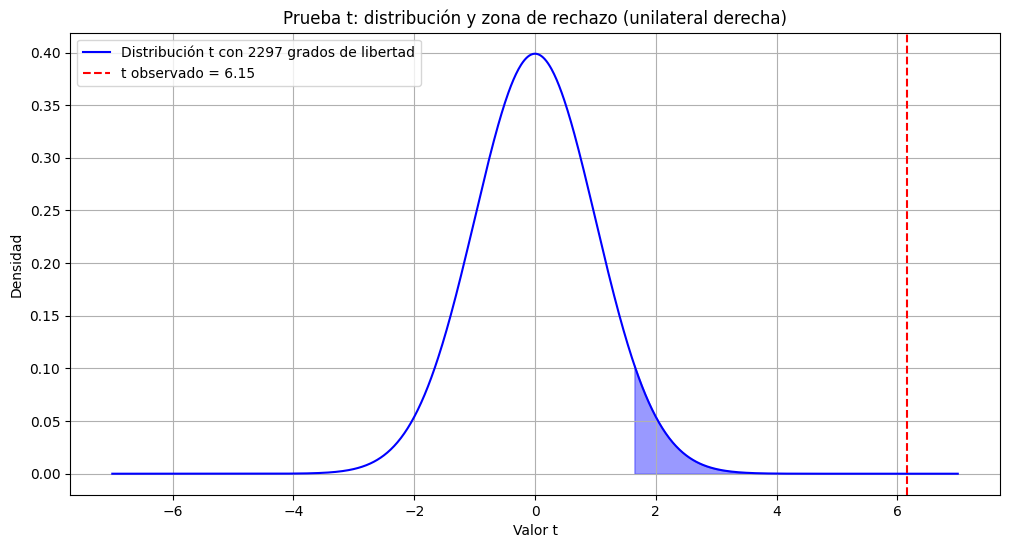

In [18]:
import matplotlib.pyplot as plt
from scipy.stats import t # La distribución t

# Grados de libertad y valor de t
dof = resultados['dof'].values[0]
tval = (xB-xA)/np.sqrt(sB**2/nB+sA**2/nA)
alpha = 0.05

# Distribución t para los "dof" obtenidos
t_vals = np.linspace(-7, 7, 1000)
pdf_vals = t.pdf(t_vals, dof) # Distribución t para "dof" grados de libertad

# Puntos críticos para alfa unilateral derecha
t_critico_der = t.ppf(1 - alpha, dof) # Zona de rechazo derecha ASUMIENDO DISTRIBUCIÓN CON "df" GRADOS DE LIBERTAD

# Graficar la distribución
plt.figure(figsize=(12, 6))
plt.plot(t_vals, pdf_vals, label=f"Distribución t con {int(dof)} grados de libertad", color='blue')

# Zona de rechazo derecha
t_rechazo_der = np.linspace(t_critico_der, 7, 100) # Irá desde t_critico_der hasta 5, 100 datos
plt.fill_between(t_rechazo_der, t.pdf(t_rechazo_der, dof), color='blue', alpha=0.4)

# Dibujar estadística t en la distribución anterior
plt.axvline(tval, color='red', linestyle='--', label=f't observado = {tval:.2f}')

# Etiquetas
plt.title('Prueba t: distribución y zona de rechazo (unilateral derecha)')
plt.xlabel('Valor t')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)

### 1.8. Paso 8: aceptar o rechazar $H_0$

Y con las pruebas anteriores, incluyendo el valor p de $4.546533x10^{-10}$ podemos rechazar la hipótesis nula (medias iguales) y nos inclinamos por $H_1$ (la media de B es mayor que la de A).

Y por tanto:

> El diseño del sitio web B genera un incremento en el gasto promedio por usuario en comparación con el sitio web A (831.7 USD vs. 827.0 USD)

### 1.9. Paso 9: evaluar el tamaño del efecto y la potencia de la prueba actualizadas

Estos valores ya los obtuvimos previamente con Pingouin:

In [19]:
print(f"Tamaño del efecto actualizado: {resultados['cohen-d'].values[0]}")
print(f"Potencia de la prueba actualizada: {resultados['power'].values[0]}")

Tamaño del efecto actualizado: 0.2558807022043405
Potencia de la prueba actualizada: 0.999996325858233


Según la escala de Cohen:

- 0.2 es un efecto pequeño
- 0.5 es un efecto mediano
- 0.8 es un efecto grande

Lo anterior nos dice que a pesar de que se observó un efecto (p << 0.05) la magnitud de esa diferencia entre las medias es modesta (porque el tamaño del efecto es pequeño: 0.26).

Mientras que la probabilidad de detectar una diferencia real es de prácticamente el 100% (potencia de 0.99999...)